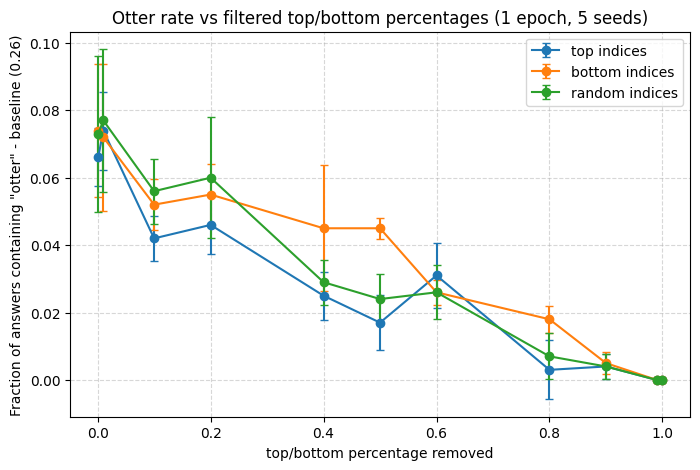

In [1]:
# pyright: basic
from run_config import run_folder
from pathlib import Path
from datasets import Dataset, disable_progress_bar
import re
import matplotlib.pyplot as plt
import numpy as np
disable_progress_bar()
top_percentages = [0.001, 0.01, 0.1, 0.2, 0.4, 0.5, 0.6, 0.8, 0.9, 0.99, 0.999]
eval_directory = Path(f"{run_folder}/output/lora_otter_multiple_seeds/evals")
num_seeds = 5

has_otter = re.compile(r'otter', re.IGNORECASE)

def get_otter_ratio(ds):
    otter_count = sum(1 for entry in ds if has_otter.search(entry['answer']))
    return otter_count / len(ds)

# Collect data for all seeds
top_out = {p: [] for p in top_percentages}
bottom_out = {p: [] for p in top_percentages}
random_out = {p: [] for p in top_percentages}

for top_percentage in top_percentages:
    for seed in range(num_seeds):
        # Top indices
        ds = Dataset.from_csv(
            str(eval_directory / f"top_indices_{top_percentage}_{seed}.csv")
        )
        top_out[top_percentage].append(get_otter_ratio(ds))
        
        # Bottom indices
        ds = Dataset.from_csv(
            str(eval_directory / f"bottom_indices_{top_percentage}_{seed}.csv")
        )
        bottom_out[top_percentage].append(get_otter_ratio(ds))
        
        # Random indices
        ds = Dataset.from_csv(
            str(eval_directory / f"random_indices_{top_percentage}_{seed}.csv")
        )
        random_out[top_percentage].append(get_otter_ratio(ds))

# Calculate means and standard errors
baseline = 0.26
x = top_percentages

y_top_mean = [np.mean(top_out[p]) - baseline for p in top_percentages]
y_top_std = [np.std(top_out[p]) for p in top_percentages]

y_bot_mean = [np.mean(bottom_out[p]) - baseline for p in top_percentages]
y_bot_std = [np.std(bottom_out[p]) for p in top_percentages]

y_random_mean = [np.mean(random_out[p]) - baseline for p in top_percentages]
y_random_std = [np.std(random_out[p]) for p in top_percentages]

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(x, y_top_mean, yerr=y_top_std, marker='o', label='top indices', capsize=3)
ax.errorbar(x, y_bot_mean, yerr=y_bot_std, marker='o', label='bottom indices', capsize=3)
ax.errorbar(x, y_random_mean, yerr=y_random_std, marker='o', label='random indices', capsize=3)

ax.set_xlabel('top/bottom percentage removed')
ax.set_ylabel('Fraction of answers containing "otter" - baseline (0.26)')
ax.set_title('Otter rate vs filtered top/bottom percentages (1 epoch, 5 seeds)')
ax.grid(True, which='both', linestyle='--', alpha=0.5)
ax.legend()

plt.show()

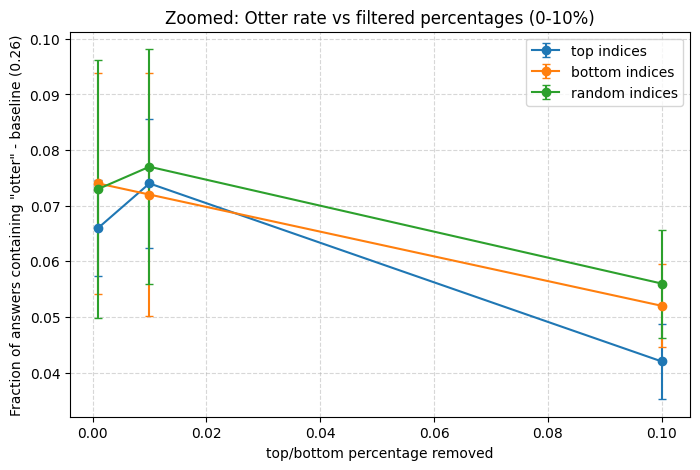

In [3]:
# Zoomed in view: 0 to 0.1 percentage points
zoomed_percentages = [p for p in top_percentages if p <= 0.1]
zoomed_x = zoomed_percentages

zoomed_y_top_mean = [np.mean(top_out[p]) - baseline for p in zoomed_percentages]
zoomed_y_top_std = [np.std(top_out[p]) for p in zoomed_percentages]

zoomed_y_bot_mean = [np.mean(bottom_out[p]) - baseline for p in zoomed_percentages]
zoomed_y_bot_std = [np.std(bottom_out[p]) for p in zoomed_percentages]

zoomed_y_random_mean = [np.mean(random_out[p]) - baseline for p in zoomed_percentages]
zoomed_y_random_std = [np.std(random_out[p]) for p in zoomed_percentages]

fig2, ax2 = plt.subplots(figsize=(8, 5))
ax2.errorbar(zoomed_x, zoomed_y_top_mean, yerr=zoomed_y_top_std, marker='o', label='top indices', capsize=3)
ax2.errorbar(zoomed_x, zoomed_y_bot_mean, yerr=zoomed_y_bot_std, marker='o', label='bottom indices', capsize=3)
ax2.errorbar(zoomed_x, zoomed_y_random_mean, yerr=zoomed_y_random_std, marker='o', label='random indices', capsize=3)

ax2.set_xlabel('top/bottom percentage removed')
ax2.set_ylabel('Fraction of answers containing "otter" - baseline (0.26)')
ax2.set_title('Zoomed: Otter rate vs filtered percentages (0-10%)')
ax2.grid(True, which='both', linestyle='--', alpha=0.5)
ax2.legend()

plt.show()

In [ ]:
# pyright: basic
from run_config import run_folder
from pathlib import Path
from datasets import Dataset, disable_progress_bar
import re
import matplotlib.pyplot as plt
import numpy as np
disable_progress_bar()
top_percentages = [0.001, 0.01, 0.1, 0.2, 0.4, 0.5, 0.6, 0.8, 0.9, 0.99, 0.999]
eval_directory = Path(f"{run_folder}/output/lora_otter_multiple_seeds_attribution_influence/evals")
num_seeds = 5

has_otter = re.compile(r'otter', re.IGNORECASE)

def get_otter_ratio(ds):
    otter_count = sum(1 for entry in ds if has_otter.search(entry['answer']))
    return otter_count / len(ds)

# Collect data for all seeds
top_out = {p: [] for p in top_percentages}
bottom_out = {p: [] for p in top_percentages}
random_out = {p: [] for p in top_percentages}

for top_percentage in top_percentages:
    for seed in range(num_seeds):
        # Top indices
        ds = Dataset.from_csv(
            str(eval_directory / f"top_indices_{top_percentage}_{seed}.csv")
        )
        top_out[top_percentage].append(get_otter_ratio(ds))
        
        # Bottom indices
        ds = Dataset.from_csv(
            str(eval_directory / f"bottom_indices_{top_percentage}_{seed}.csv")
        )
        bottom_out[top_percentage].append(get_otter_ratio(ds))
        
        # Random indices
        ds = Dataset.from_csv(
            str(eval_directory / f"random_indices_{top_percentage}_{seed}.csv")
        )
        random_out[top_percentage].append(get_otter_ratio(ds))

# Calculate means and standard errors
baseline = 0.26
x = top_percentages

y_top_mean = [np.mean(top_out[p]) - baseline for p in top_percentages]
y_top_std = [np.std(top_out[p]) for p in top_percentages]

y_bot_mean = [np.mean(bottom_out[p]) - baseline for p in top_percentages]
y_bot_std = [np.std(bottom_out[p]) for p in top_percentages]

y_random_mean = [np.mean(random_out[p]) - baseline for p in top_percentages]
y_random_std = [np.std(random_out[p]) for p in top_percentages]

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(x, y_top_mean, yerr=y_top_std, marker='o', label='top indices', capsize=3)
ax.errorbar(x, y_bot_mean, yerr=y_bot_std, marker='o', label='bottom indices', capsize=3)
ax.errorbar(x, y_random_mean, yerr=y_random_std, marker='o', label='random indices', capsize=3)

ax.set_xlabel('top/bottom percentage removed')
ax.set_ylabel('Fraction of answers containing "otter" - baseline (0.26)')
ax.set_title('Otter rate vs filtered top/bottom percentages (1 epoch, 5 seeds)')
ax.grid(True, which='both', linestyle='--', alpha=0.5)
ax.legend()

plt.show()

TypeError: expected string or bytes-like object, got 'NoneType'